In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import joblib
import random
import time
import os

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

In [2]:
df = pd.read_csv("diabetes_prediction_dataset.csv")
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (100000, 9)

First 5 rows:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [4]:
print("Dataset information:")
df.info()

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 8.0 MB


In [5]:
print("Descriptive statistics:")
display(df.describe())
print("Categorical feature statistics:")
display(df.describe(include="object"))

Descriptive statistics:


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


Categorical feature statistics:


C:\Users\vuthu\AppData\Local\Temp\ipykernel_10840\1687900543.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object"))


,gender,smoking_history
count,100000,100000
unique,3,6
top,Female,No Info
freq,58552,35816


In [6]:
missing_values = df.isna().sum()

print("Missing values per column:")
display(missing_values)

Missing values per column:


gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [7]:
duplicate_count = df.duplicated().sum()

print("Number of duplicated records:", duplicate_count)
print("Duplicate percentage:", duplicate_count / len(df) * 100, "%")

Number of duplicated records: 3854
Duplicate percentage: 3.8539999999999996 %


In [10]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

TARGET = "diabetes"

X = df.drop(columns=[TARGET])
y = df[TARGET]

print("Target column:", TARGET)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Numerical columns:
['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Categorical columns:
['gender', 'smoking_history']
Target column: diabetes

X shape: (100000, 8)
y shape: (100000,)


C:\Users\vuthu\AppData\Local\Temp\ipykernel_10840\3333222365.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


In [11]:
numerical_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']

Categorical features:
['gender', 'smoking_history']


In [12]:
print("Target distribution:")
display(y.value_counts().sort_index())

print("\nTarget percentage:")
display(
    (y.value_counts(normalize=True).sort_index() * 100).round(2)
)

Target distribution:


diabetes
0    91500
1     8500
Name: count, dtype: int64


Target percentage:


diabetes
0    91.5
1     8.5
Name: proportion, dtype: float64

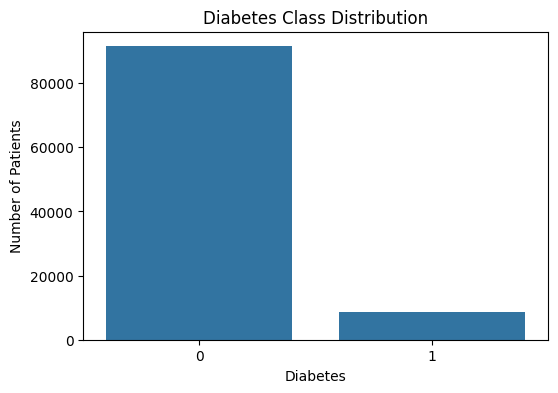

In [13]:
plt.figure(figsize=(6, 4))

sns.countplot(x=y)

plt.title("Diabetes Class Distribution")
plt.xlabel("Diabetes")
plt.ylabel("Number of Patients")

plt.show()

In [14]:
print("Unique target values:")
print(sorted(y.unique()))

invalid_target_values = y[~y.isin([0, 1])]

print("\nNumber of invalid target values:", len(invalid_target_values))

Unique target values:
[np.int64(0), np.int64(1)]

Number of invalid target values: 0


In [15]:
numerical_summary = pd.DataFrame({
    "dtype": X[numerical_features].dtypes,
    "min": X[numerical_features].min(),
    "max": X[numerical_features].max(),
    "mean": X[numerical_features].mean(),
    "std": X[numerical_features].std()
})

display(numerical_summary)

,dtype,min,max,mean,std
age,float64,0.08,80.00,41.885856,22.516840
hypertension,int64,0.00,1.00,0.074850,0.263150
heart_disease,int64,0.00,1.00,0.039420,0.194593
bmi,float64,10.01,95.69,27.320767,6.636783
HbA1c_level,float64,3.50,9.00,5.527507,1.070672
blood_glucose_level,int64,80.00,300.00,138.058060,40.708136


In [16]:
binary_features = ["hypertension", "heart_disease"]

for col in binary_features:
    print(f"{col}:")
    print(sorted(X[col].unique()))
    print()

hypertension:
[np.int64(0), np.int64(1)]

heart_disease:
[np.int64(0), np.int64(1)]



In [17]:
for col in categorical_features:
    print(f"\n{col}:")
    print(X[col].value_counts(dropna=False))


gender:
gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

smoking_history:
smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


In [19]:
duplicate_count = df.duplicated().sum()

print("Original number of rows:", len(df))
print("Number of duplicated rows:", duplicate_count)
print(
    "Duplicate percentage:",
    round(duplicate_count / len(df) * 100, 2),
    "%"
)
df_clean = df.drop_duplicates().copy()

print("Rows after removing duplicates:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original number of rows: 100000
Number of duplicated rows: 3854
Duplicate percentage: 3.85 %
Rows after removing duplicates: 96146
Rows removed: 3854


In [20]:
print("Invalid value analysis")
print("-" * 50)

invalid_checks = {
    "age <= 0": (X["age"] <= 0).sum(),
    "age > 100": (X["age"] > 100).sum(),
    "bmi <= 0": (X["bmi"] <= 0).sum(),
    "HbA1c_level <= 0": (X["HbA1c_level"] <= 0).sum(),
    "blood_glucose_level <= 0": (X["blood_glucose_level"] <= 0).sum(),
}

for condition, count in invalid_checks.items():
    print(f"{condition}: {count}")

Invalid value analysis
--------------------------------------------------
age <= 0: 0
age > 100: 0
bmi <= 0: 0
HbA1c_level <= 0: 0
blood_glucose_level <= 0: 0


In [21]:
binary_features = ["hypertension", "heart_disease"]

for col in binary_features:
    invalid_values = X.loc[~X[col].isin([0, 1]), col]
    
    print(f"{col}:")
    print("  Unique values:", sorted(X[col].unique()))
    print("  Invalid values:", len(invalid_values))
    print()

hypertension:
  Unique values: [np.int64(0), np.int64(1)]
  Invalid values: 0

heart_disease:
  Unique values: [np.int64(0), np.int64(1)]
  Invalid values: 0



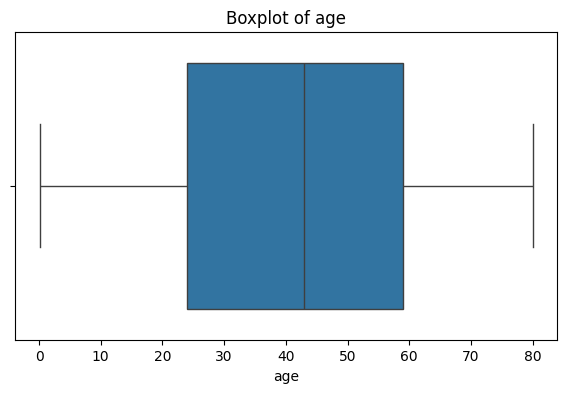

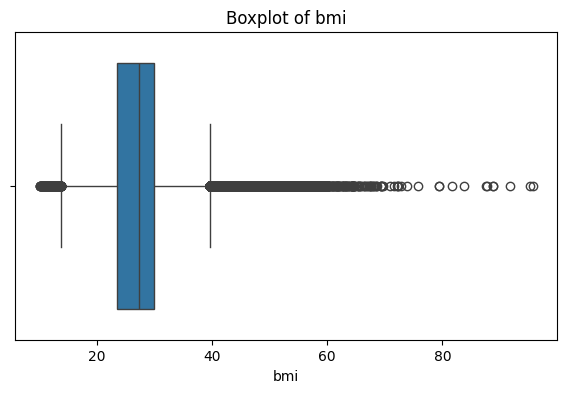

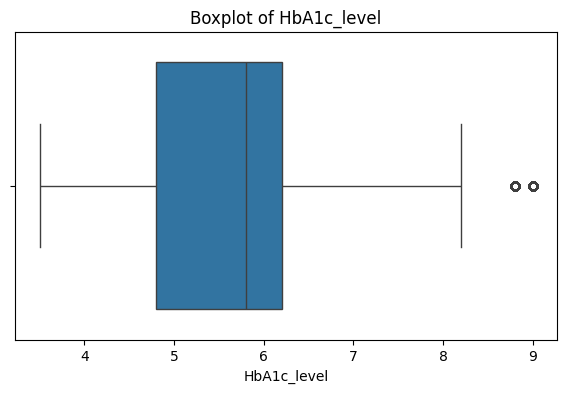

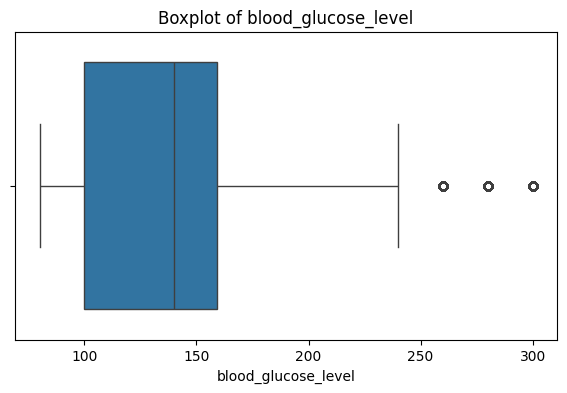

In [22]:
continuous_features = [
    "age",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level"
]

for col in continuous_features:
    plt.figure(figsize=(7, 4))
    
    sns.boxplot(x=df_clean[col])
    
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    
    plt.show()

In [23]:
outlier_summary = []

for col in continuous_features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_clean[
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    ]
    
    outlier_summary.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier Percentage": len(outliers) / len(df_clean) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,age,24.0,59.00,35.00,-28.50,111.50,0,0.000000
1,bmi,23.4,29.86,6.46,13.71,39.55,5354,5.568614
2,HbA1c_level,4.8,6.20,1.40,2.70,8.30,1312,1.364591
3,blood_glucose_level,100.0,159.00,59.00,11.50,247.50,2031,2.112412


In [25]:
df_clean = df.drop_duplicates().copy()
print("Cleaned dataset shape:", df_clean.shape)

Cleaned dataset shape: (96146, 9)


In [26]:
TARGET = "diabetes"

X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

print("Cleaned X shape:", X.shape)
print("Cleaned y shape:", y.shape)

Cleaned X shape: (96146, 8)
Cleaned y shape: (96146,)


In [27]:
print("Duplicates after cleaning:", df_clean.duplicated().sum())

Duplicates after cleaning: 0


In [28]:
print("Missing values after cleaning:")

display(df_clean.isna().sum())

Missing values after cleaning:


gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [29]:
# Create a clean copy of the dataset
df_clean = df.copy()

# Remove duplicated records
before_duplicates = len(df_clean)

df_clean = df_clean.drop_duplicates().copy()

after_duplicates = len(df_clean)
duplicates_removed = before_duplicates - after_duplicates

print("Data cleaning summary")
print("-" * 50)
print(f"Original rows:        {before_duplicates:,}")
print(f"Duplicates removed:   {duplicates_removed:,}")
print(f"Cleaned rows:         {after_duplicates:,}")
print(f"Remaining columns:    {df_clean.shape[1]}")

Data cleaning summary
--------------------------------------------------
Original rows:        100,000
Duplicates removed:   3,854
Cleaned rows:         96,146
Remaining columns:    9


In [30]:
print("Data quality after cleaning")
print("-" * 50)

print("Shape:", df_clean.shape)

print("\nMissing values:")
print(df_clean.isna().sum())

print("\nDuplicated records:")
print(df_clean.duplicated().sum())

Data quality after cleaning
--------------------------------------------------
Shape: (96146, 9)

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicated records:
0


In [31]:
TARGET = "diabetes"

X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

print("Feature matrix X shape:", X.shape)
print("Target vector y shape:", y.shape)

Feature matrix X shape: (96146, 8)
Target vector y shape: (96146,)


In [32]:
numerical_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']

Categorical features:
['gender', 'smoking_history']


In [33]:
cleaning_summary = pd.DataFrame({
    "Issue": [
        "Missing values",
        "Duplicate records",
        "Invalid target values",
        "Invalid binary values",
        "Statistical outliers"
    ],
    "Result": [
        "None detected",
        "3,854 removed",
        "None detected",
        "None detected",
        "Detected but retained"
    ],
    "Action": [
        "No treatment required",
        "Removed",
        "No treatment required",
        "No treatment required",
        "Not removed automatically"
    ]
})

display(cleaning_summary)

,Issue,Result,Action
0,Missing values,None detected,No treatment required
1,Duplicate records,"3,854 removed",Removed
2,Invalid target values,None detected,No treatment required
3,Invalid binary values,None detected,No treatment required
4,Statistical outliers,Detected but retained,Not removed automatically


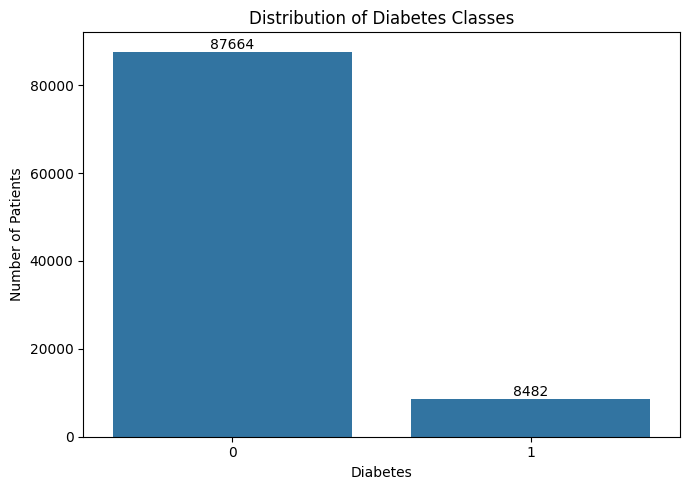

In [34]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df_clean,
    x="diabetes"
)

plt.title("Distribution of Diabetes Classes")
plt.xlabel("Diabetes")
plt.ylabel("Number of Patients")

# Add count labels
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [35]:
target_distribution = (
    df_clean["diabetes"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("Target distribution (%):")
display(target_distribution.round(2))

Target distribution (%):


diabetes
0    91.18
1     8.82
Name: proportion, dtype: float64

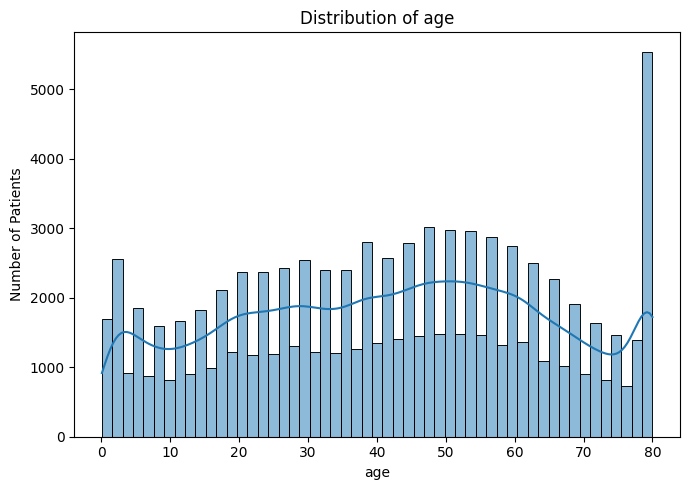

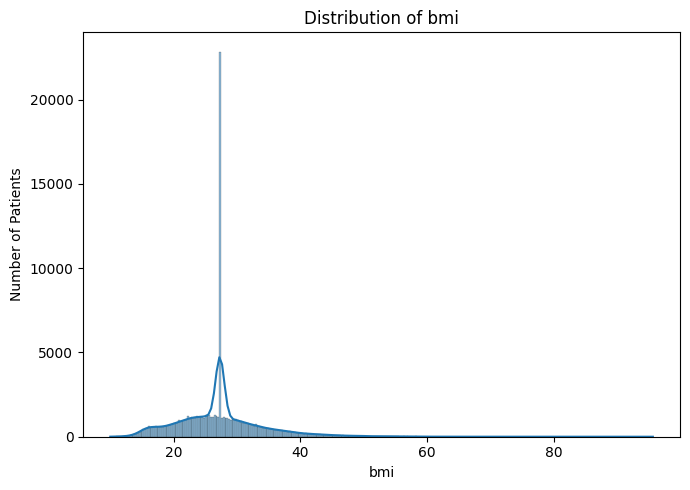

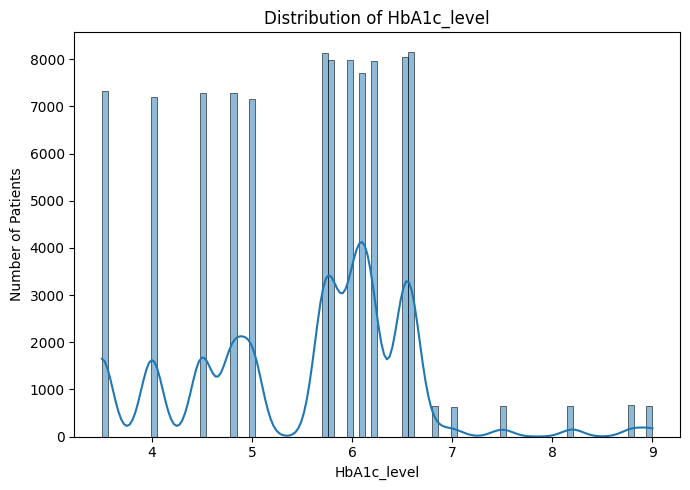

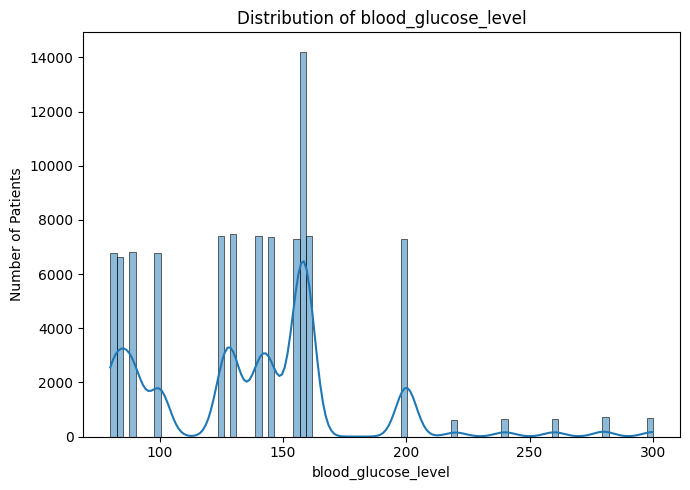

In [36]:
continuous_features = [
    "age",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level"
]

for col in continuous_features:
    plt.figure(figsize=(7, 5))
    
    sns.histplot(
        data=df_clean,
        x=col,
        kde=True
    )
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Patients")
    
    plt.tight_layout()
    plt.show()

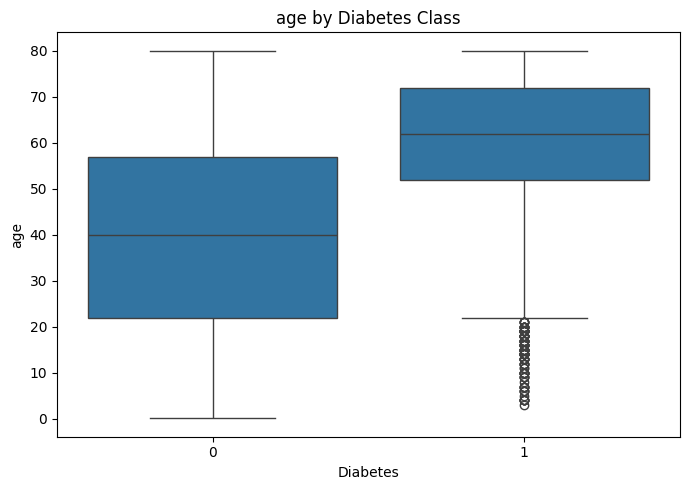

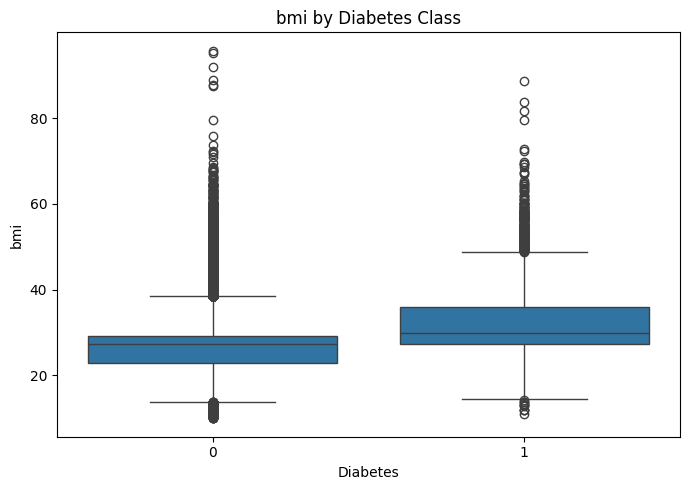

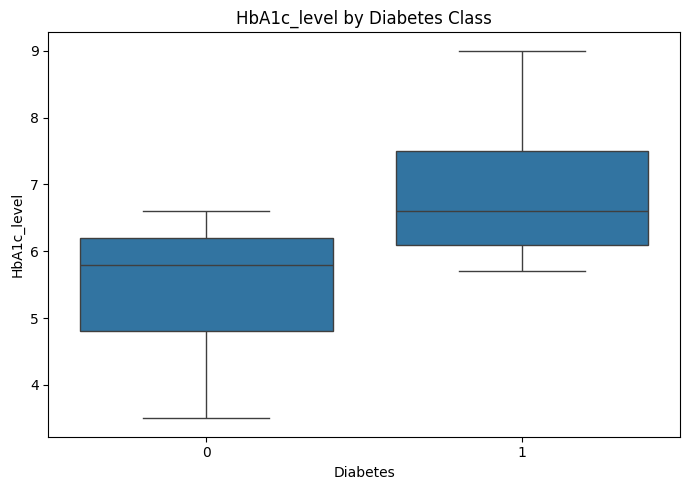

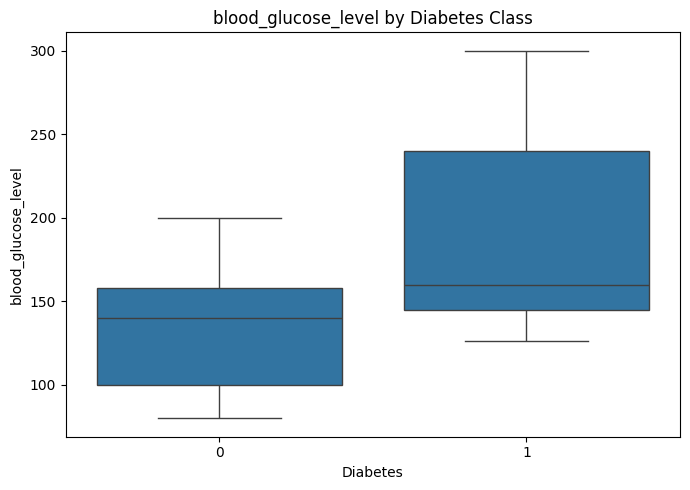

In [37]:
for col in continuous_features:
    plt.figure(figsize=(7, 5))
    
    sns.boxplot(
        data=df_clean,
        x="diabetes",
        y=col
    )
    
    plt.title(f"{col} by Diabetes Class")
    plt.xlabel("Diabetes")
    plt.ylabel(col)
    
    plt.tight_layout()
    plt.show()

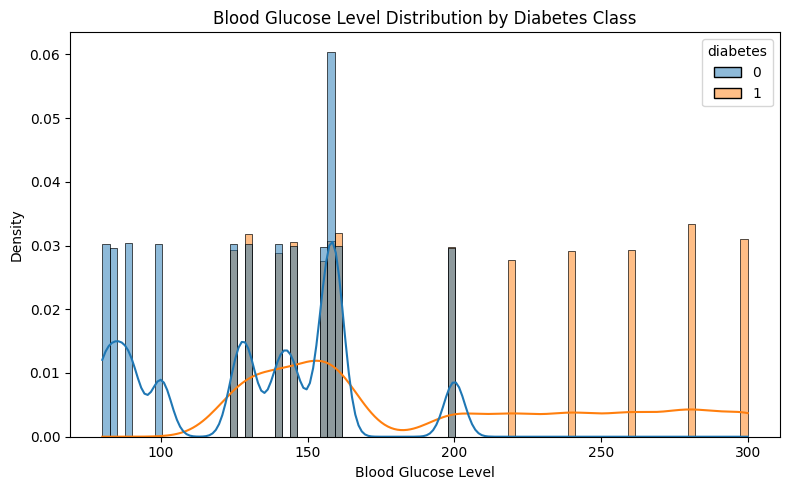

In [38]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="blood_glucose_level",
    hue="diabetes",
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("Blood Glucose Level Distribution by Diabetes Class")
plt.xlabel("Blood Glucose Level")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

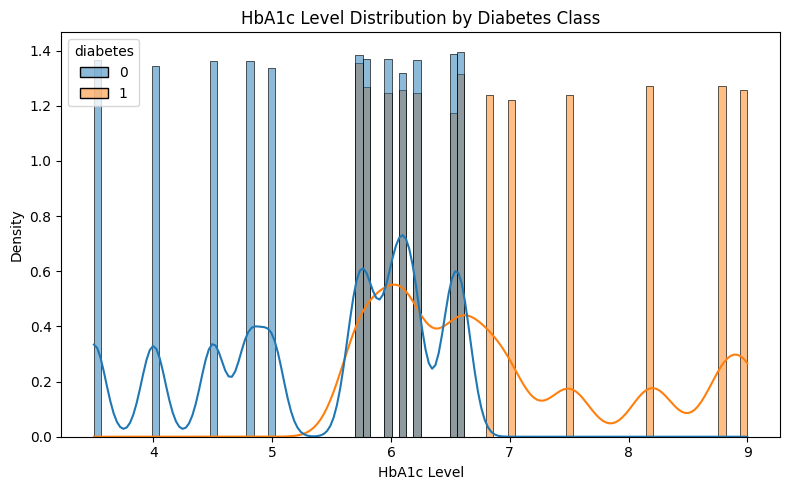

In [39]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="HbA1c_level",
    hue="diabetes",
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("HbA1c Level Distribution by Diabetes Class")
plt.xlabel("HbA1c Level")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

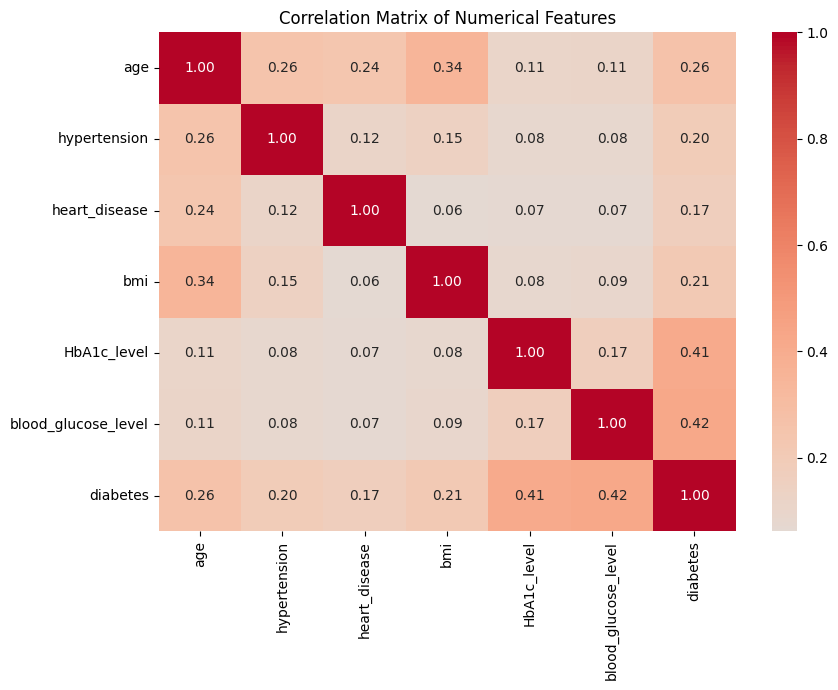

In [40]:
correlation_columns = [
    "age",
    "hypertension",
    "heart_disease",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level",
    "diabetes"
]

correlation_matrix = df_clean[correlation_columns].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()
plt.show()

In [41]:
target_correlation = (
    correlation_matrix["diabetes"]
    .drop("diabetes")
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
)

print("Correlation with diabetes:")
display(target_correlation.to_frame("Correlation"))

Correlation with diabetes:


,Correlation
blood_glucose_level,0.424336
HbA1c_level,0.406408
age,0.264927
bmi,0.214932
hypertension,0.195710
heart_disease,0.170711


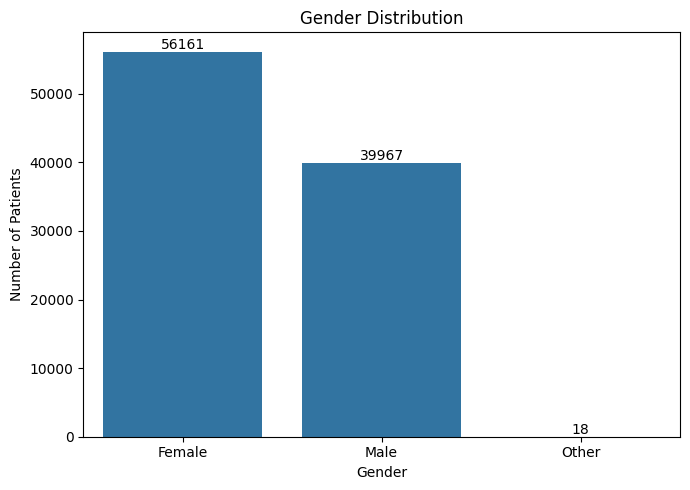

In [42]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df_clean,
    x="gender",
    order=df_clean["gender"].value_counts().index
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

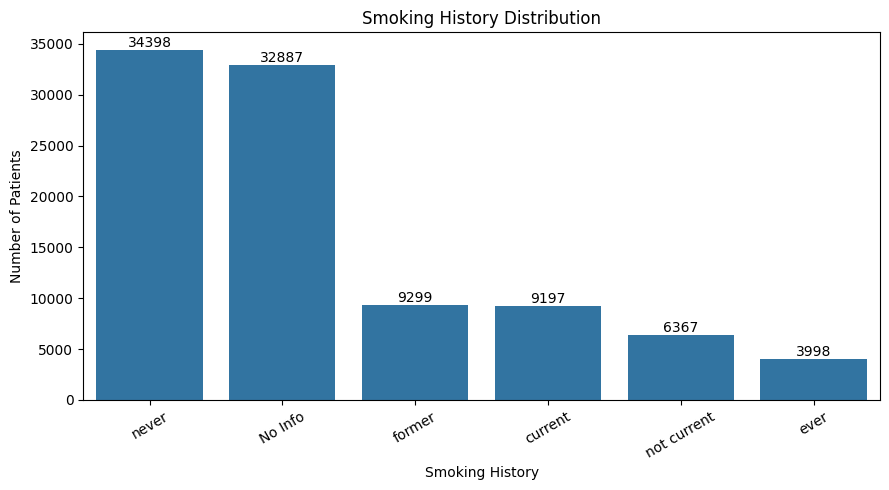

In [43]:
plt.figure(figsize=(9, 5))

ax = sns.countplot(
    data=df_clean,
    x="smoking_history",
    order=df_clean["smoking_history"].value_counts().index
)

plt.title("Smoking History Distribution")
plt.xlabel("Smoking History")
plt.ylabel("Number of Patients")

plt.xticks(rotation=30)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [44]:
gender_diabetes = pd.crosstab(
    df_clean["gender"],
    df_clean["diabetes"],
    normalize="index"
) * 100

display(gender_diabetes.round(2))

diabetes,0,1
gender,,
Female,92.08,7.92
Male,89.90,10.10
Other,100.00,0.00


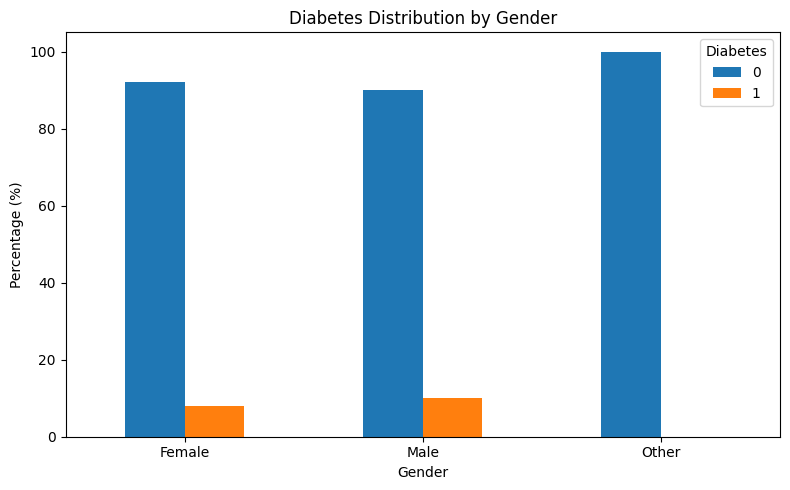

In [45]:
gender_diabetes.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Diabetes Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Diabetes")

plt.tight_layout()
plt.show()

In [46]:
smoking_diabetes = pd.crosstab(
    df_clean["smoking_history"],
    df_clean["diabetes"],
    normalize="index"
) * 100

display(smoking_diabetes.round(2))

diabetes,0,1
smoking_history,,
No Info,95.61,4.39
current,89.69,10.31
ever,88.19,11.81
former,82.90,17.10
never,90.30,9.70
not current,89.16,10.84


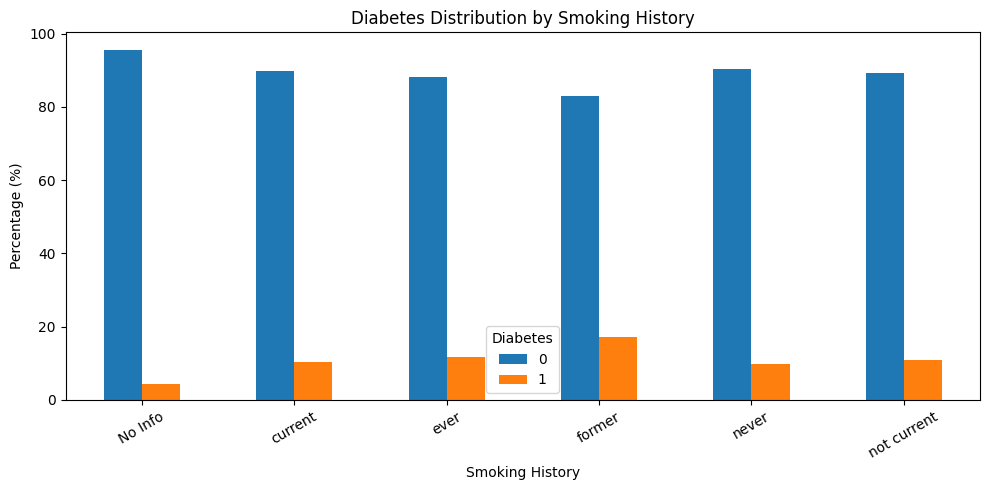

In [47]:
smoking_diabetes.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Diabetes Distribution by Smoking History")
plt.xlabel("Smoking History")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=30)
plt.legend(title="Diabetes")

plt.tight_layout()
plt.show()

In [48]:
# Display one patient observation
display(df_clean.iloc[[0]])
# Display the input features of one patient
sample_vector = X.iloc[0]

print("One patient feature vector:")
display(sample_vector)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0


One patient feature vector:


gender                 Female
age                      80.0
hypertension                0
heart_disease               1
smoking_history         never
bmi                     25.19
HbA1c_level               6.6
blood_glucose_level       140
Name: 0, dtype: object

In [49]:
print("Feature matrix shape:", X.shape)

N, d = X.shape

print(f"N (number of observations): {N:,}")
print(f"d (number of input features): {d}")

Feature matrix shape: (96146, 8)
N (number of observations): 96,146
d (number of input features): 8


In [50]:
print("First 5 observations of X:")
display(X.head())
print("Feature names:")
for i, feature in enumerate(X.columns, start=1):
    print(f"{i}. {feature}")

First 5 observations of X:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,Female,80.0,0,1,never,25.19,6.6,140
1,Female,54.0,0,0,No Info,27.32,6.6,80
2,Male,28.0,0,0,never,27.32,5.7,158
3,Female,36.0,0,0,current,23.45,5.0,155
4,Male,76.0,1,1,current,20.14,4.8,155


Feature names:
1. gender
2. age
3. hypertension
4. heart_disease
5. smoking_history
6. bmi
7. HbA1c_level
8. blood_glucose_level


In [51]:
print("Data types of input features:")
display(X.dtypes)

Data types of input features:


gender                     str
age                    float64
hypertension             int64
heart_disease            int64
smoking_history            str
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
dtype: object

In [52]:
print("Numerical feature ranges before preprocessing:")

range_table = pd.DataFrame({
    "Min": X[numerical_features].min(),
    "Max": X[numerical_features].max(),
    "Mean": X[numerical_features].mean(),
    "Std": X[numerical_features].std()
})

display(range_table)

Numerical feature ranges before preprocessing:


,Min,Max,Mean,Std
age,0.08,80.00,41.794326,22.462948
hypertension,0.00,1.00,0.077601,0.267544
heart_disease,0.00,1.00,0.040803,0.197833
bmi,10.01,95.69,27.321461,6.767716
HbA1c_level,3.50,9.00,5.532609,1.073232
blood_glucose_level,80.00,300.00,138.218231,40.909771


In [53]:
for col in categorical_features:
    print(f"\n{col}")
    print("Unique values:")
    print(X[col].unique())
for col in categorical_features:
    print(f"\nValue counts for {col}:")
    display(X[col].value_counts())


gender
Unique values:
<ArrowStringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str

smoking_history
Unique values:
<ArrowStringArray>
['never', 'No Info', 'current', 'former', 'ever', 'not current']
Length: 6, dtype: str

Value counts for gender:


gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64


Value counts for smoking_history:


smoking_history
never          34398
No Info        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64

In [54]:
numerical_features = [
    "age",
    "hypertension",
    "heart_disease",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level"
]

categorical_features = [
    "gender",
    "smoking_history"
]

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)
TARGET = "diabetes"

Numerical features: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']
Categorical features: ['gender', 'smoking_history']


In [55]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=y_temp
)

print("Dataset split:")
print("-" * 40)

print(f"Training set:   {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set:       {X_test.shape}")

print("\nTarget shapes:")
print(f"y_train: {y_train.shape}")
print(f"y_val:   {y_val.shape}")
print(f"y_test:  {y_test.shape}")

Dataset split:
----------------------------------------
Training set:   (67302, 8)
Validation set: (14422, 8)
Test set:       (14422, 8)

Target shapes:
y_train: (67302,)
y_val:   (14422,)
y_test:  (14422,)


In [56]:
split_distribution = pd.DataFrame({
    "Train": y_train.value_counts(normalize=True),
    "Validation": y_val.value_counts(normalize=True),
    "Test": y_test.value_counts(normalize=True)
}) * 100

display(split_distribution.round(2))

,Train,Validation,Test
diabetes,,,
0,91.18,91.17,91.18
1,8.82,8.83,8.82


In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

In [58]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)

In [59]:
print("Processed feature matrix shapes:")
print(f"X_train_processed: {X_train_processed.shape}")
print(f"X_val_processed:   {X_val_processed.shape}")
print(f"X_test_processed:  {X_test_processed.shape}")

Processed feature matrix shapes:
X_train_processed: (67302, 15)
X_val_processed:   (14422, 15)
X_test_processed:  (14422, 15)


In [60]:
feature_names = preprocessor.get_feature_names_out()

print("Number of final features:", len(feature_names))

print("\nFinal feature names:")
for i, feature in enumerate(feature_names, start=1):
    print(f"{i}. {feature}")

Number of final features: 15

Final feature names:
1. num__age
2. num__hypertension
3. num__heart_disease
4. num__bmi
5. num__HbA1c_level
6. num__blood_glucose_level
7. cat__gender_Female
8. cat__gender_Male
9. cat__gender_Other
10. cat__smoking_history_No Info
11. cat__smoking_history_current
12. cat__smoking_history_ever
13. cat__smoking_history_former
14. cat__smoking_history_never
15. cat__smoking_history_not current


In [61]:
print("Final model-input representation")
print("-" * 50)

print("Shape:", X_train_processed.shape)
print("Dtype:", X_train_processed.dtype)
print("Min:", X_train_processed.min())
print("Max:", X_train_processed.max())
print("Mean:", X_train_processed.mean())
print("Std:", X_train_processed.std())

Final model-input representation
--------------------------------------------------
Shape: (67302, 15)
Dtype: float64
Min: -2.5629340621182135
Max: 10.063744258130992
Mean: 0.13333333333333336
Std: 0.7180219742846005


In [62]:
processed_sample = X_train_processed[0]

print("One processed patient feature vector:")
print(processed_sample)

print("\nVector dimension:")
print(processed_sample.shape)

One processed patient feature vector:
[ 0.81280525 -0.29075169 -0.20636173 -0.24238738  0.43742462 -1.17574744
  0.          1.          0.          0.          0.          0.
  0.          1.          0.        ]

Vector dimension:
(15,)


In [63]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

display(X_train_processed_df.head())

,num__age,num__hypertension,num__heart_disease,num__bmi,num__HbA1c_level,num__blood_glucose_level,cat__gender_Female,cat__gender_Male,cat__gender_Other,cat__smoking_history_No Info,cat__smoking_history_current,cat__smoking_history_ever,cat__smoking_history_former,cat__smoking_history_never,cat__smoking_history_not current
70233,0.812805,-0.290752,-0.206362,-0.242387,0.437425,-1.175747,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
95154,-0.612356,-0.290752,-0.206362,-0.288324,-1.890696,0.535126,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
55028,-0.478747,-0.290752,-0.206362,0.002115,0.623674,1.512767,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
19688,-1.725764,-0.290752,-0.206362,-1.162604,-0.680073,0.412920,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1674,0.144761,-0.290752,4.845860,-1.036649,0.623674,-0.198106,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [65]:
encoded_categorical_features = [
    feature for feature in feature_names
    if feature.startswith("cat__")
]

print("Encoded categorical features:")
for feature in encoded_categorical_features:
    print(feature)
display(
    X_train_processed_df[encoded_categorical_features].head()
)

Encoded categorical features:
cat__gender_Female
cat__gender_Male
cat__gender_Other
cat__smoking_history_No Info
cat__smoking_history_current
cat__smoking_history_ever
cat__smoking_history_former
cat__smoking_history_never
cat__smoking_history_not current


,cat__gender_Female,cat__gender_Male,cat__gender_Other,cat__smoking_history_No Info,cat__smoking_history_current,cat__smoking_history_ever,cat__smoking_history_former,cat__smoking_history_never,cat__smoking_history_not current
70233,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
95154,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
55028,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
19688,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1674,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [66]:
scaled_numerical_features = [
    feature for feature in feature_names
    if feature.startswith("num__")
]

print("Scaled numerical features:")
display(
    X_train_processed_df[scaled_numerical_features].head()
)

Scaled numerical features:


,num__age,num__hypertension,num__heart_disease,num__bmi,num__HbA1c_level,num__blood_glucose_level
70233,0.812805,-0.290752,-0.206362,-0.242387,0.437425,-1.175747
95154,-0.612356,-0.290752,-0.206362,-0.288324,-1.890696,0.535126
55028,-0.478747,-0.290752,-0.206362,0.002115,0.623674,1.512767
19688,-1.725764,-0.290752,-0.206362,-1.162604,-0.680073,0.412920
1674,0.144761,-0.290752,4.845860,-1.036649,0.623674,-0.198106


In [67]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(
    strategy="most_frequent"
)

start_time = time.time()

baseline.fit(X_train_processed, y_train)

baseline_training_time = time.time() - start_time

baseline_pred = baseline.predict(X_val_processed)
baseline_prob = baseline.predict_proba(X_val_processed)[:, 1]

In [68]:
def calculate_classification_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true, y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true, y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_true, y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_true, y_prob
        )
    }
baseline_metrics = calculate_classification_metrics(
    y_val,
    baseline_pred,
    baseline_prob
)

baseline_metrics["Training Time (s)"] = baseline_training_time

display(
    pd.DataFrame([baseline_metrics], index=["Dummy Classifier"])
)

,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s)
Dummy Classifier,0.911732,0.0,0.0,0.0,0.5,0.002817


In [69]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_SEED
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_SEED
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_SEED,
        n_jobs=-1
    ),

    "SVM": SVC(
        probability=True,
        random_state=RANDOM_SEED
    )
}

In [70]:
trained_models = {}
validation_results = []

for model_name, model in models.items():

    print(f"Training {model_name}...")

    start_time = time.time()

    model.fit(
        X_train_processed,
        y_train
    )

    training_time = time.time() - start_time

    y_val_pred = model.predict(X_val_processed)

    y_val_prob = model.predict_proba(
        X_val_processed
    )[:, 1]

    metrics = calculate_classification_metrics(
        y_val,
        y_val_pred,
        y_val_prob
    )

    metrics["Model"] = model_name
    metrics["Training Time (s)"] = training_time

    validation_results.append(metrics)

    trained_models[model_name] = model

    print(
        f"{model_name} completed "
        f"in {training_time:.2f} seconds."
    )

Training Logistic Regression...
Logistic Regression completed in 0.10 seconds.
Training KNN...
KNN completed in 0.36 seconds.
Training Decision Tree...
Decision Tree completed in 0.31 seconds.
Training Random Forest...
Random Forest completed in 2.63 seconds.
Training SVM...
SVM completed in 261.64 seconds.


In [71]:
validation_results_df = pd.DataFrame(
    validation_results
)

validation_results_df = validation_results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "Training Time (s)"
    ]
]

validation_results_df = validation_results_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

display(
    validation_results_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s)
0,Random Forest,0.9672,0.9435,0.6685,0.7825,0.9557,2.6269
1,SVM,0.9596,0.9688,0.5601,0.7098,0.9239,261.6430
2,Logistic Regression,0.9562,0.8589,0.6025,0.7082,0.9557,0.0958
3,KNN,0.9569,0.8817,0.5915,0.7080,0.8905,0.3621
4,Decision Tree,0.9472,0.6925,0.7235,0.7076,0.8468,0.3113


In [72]:
baseline_row = pd.DataFrame([{
    "Model": "Dummy Classifier",
    "Accuracy": baseline_metrics["Accuracy"],
    "Precision": baseline_metrics["Precision"],
    "Recall": baseline_metrics["Recall"],
    "F1": baseline_metrics["F1"],
    "ROC-AUC": baseline_metrics["ROC-AUC"],
    "Training Time (s)": baseline_metrics["Training Time (s)"]
}])

comparison_with_baseline = pd.concat(
    [baseline_row, validation_results_df],
    ignore_index=True
)

display(
    comparison_with_baseline.round(4)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s)
0,Dummy Classifier,0.9117,0.0000,0.0000,0.0000,0.5000,0.0028
1,Random Forest,0.9672,0.9435,0.6685,0.7825,0.9557,2.6269
2,SVM,0.9596,0.9688,0.5601,0.7098,0.9239,261.6430
3,Logistic Regression,0.9562,0.8589,0.6025,0.7082,0.9557,0.0958
4,KNN,0.9569,0.8817,0.5915,0.7080,0.8905,0.3621
5,Decision Tree,0.9472,0.6925,0.7235,0.7076,0.8468,0.3113


In [75]:
for model_name, model in trained_models.items():

    y_val_pred = model.predict(X_val_processed)

    cm = confusion_matrix(
        y_val,
        y_val_pred
    )

    print(f"\n{model_name}")
    print(cm)


Logistic Regression
[[13023   126]
 [  506   767]]

KNN
[[13048   101]
 [  520   753]]

Decision Tree
[[12740   409]
 [  352   921]]

Random Forest
[[13098    51]
 [  422   851]]

SVM
[[13126    23]
 [  560   713]]


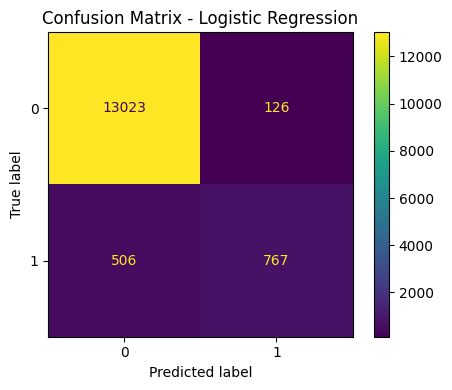

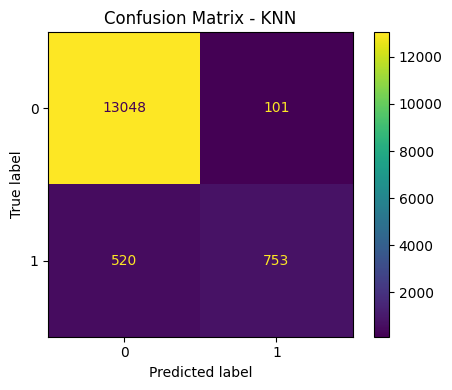

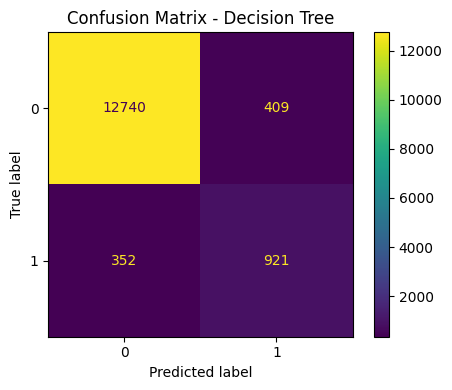

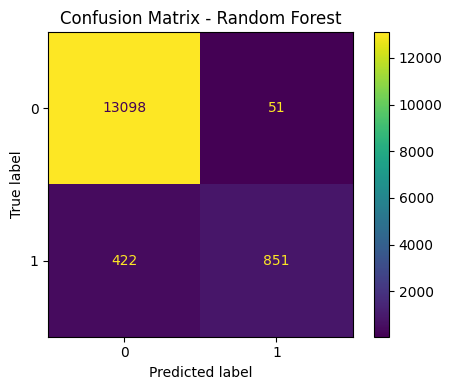

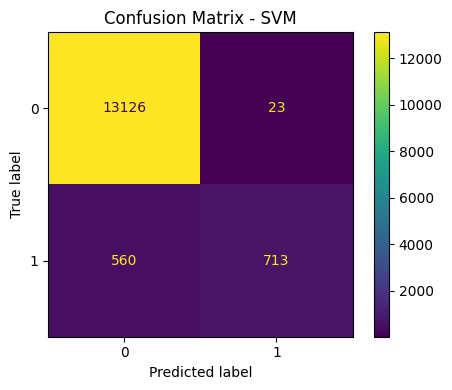

In [77]:
for model_name, model in trained_models.items():

    y_val_pred = model.predict(X_val_processed)

    fig, ax = plt.subplots(figsize=(5, 4))

    ConfusionMatrixDisplay.from_predictions(
        y_val,
        y_val_pred,
        ax=ax
    )

    ax.set_title(
        f"Confusion Matrix - {model_name}"
    )

    plt.tight_layout()
    plt.show()

<Figure size 800x600 with 0 Axes>

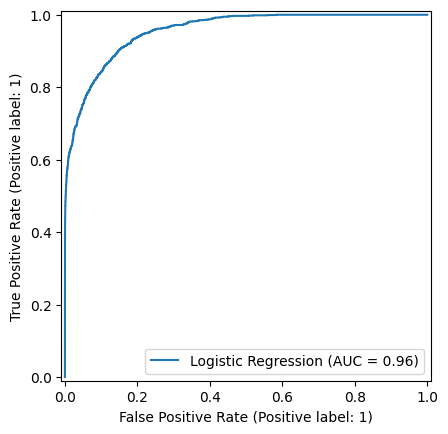

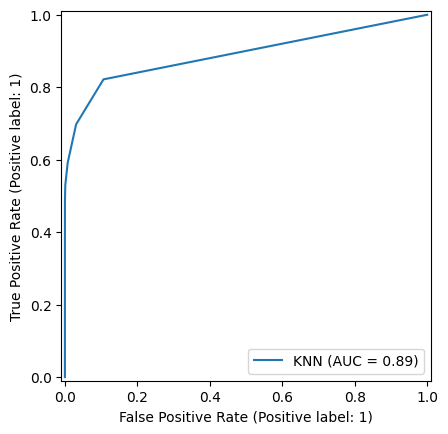

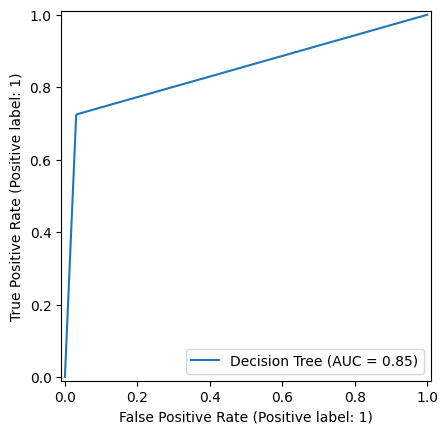

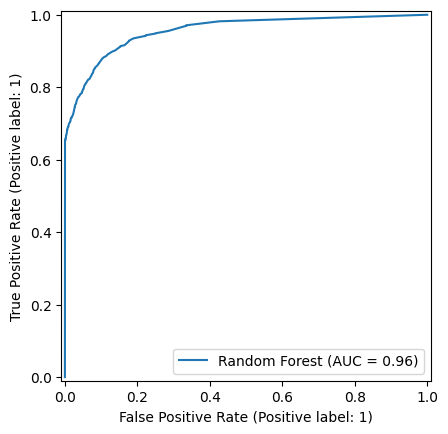

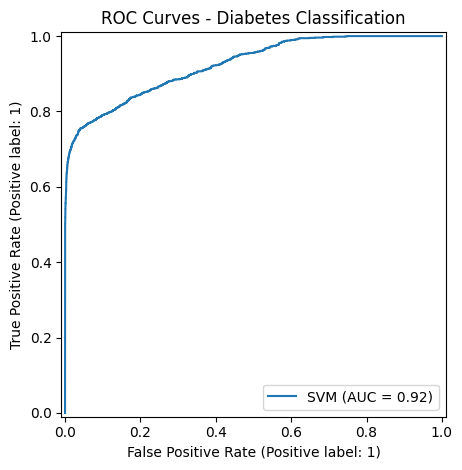

In [78]:
plt.figure(figsize=(8, 6))

for model_name, model in trained_models.items():

    y_val_prob = model.predict_proba(
        X_val_processed
    )[:, 1]

    RocCurveDisplay.from_predictions(
        y_val,
        y_val_prob,
        name=model_name
    )

plt.title("ROC Curves - Diabetes Classification")
plt.tight_layout()
plt.show()

In [79]:
best_model_name = validation_results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("Best validation model based on F1-score:")
print(best_model_name)

Best validation model based on F1-score:
Random Forest


In [80]:
# Predict on the independent test set

y_test_pred = best_model.predict(X_test_processed)

y_test_prob = best_model.predict_proba(
    X_test_processed
)[:, 1]

print("Test prediction completed.")

Test prediction completed.


In [81]:
# Calculate final test metrics

final_test_metrics = calculate_classification_metrics(
    y_test,
    y_test_pred,
    y_test_prob
)

final_test_results = pd.DataFrame(
    [final_test_metrics],
    index=[best_model_name]
)

display(
    final_test_results.round(4)
)

,Accuracy,Precision,Recall,F1,ROC-AUC
Random Forest,0.971,0.9495,0.7091,0.8119,0.9617


In [82]:
# Detailed classification report

print(f"Classification Report - {best_model_name}")

print(
    classification_report(
        y_test,
        y_test_pred,
        digits=4,
        zero_division=0
    )
)

Classification Report - Random Forest
              precision    recall  f1-score   support

           0     0.9725    0.9963    0.9843     13150
           1     0.9495    0.7091    0.8119      1272

    accuracy                         0.9710     14422
   macro avg     0.9610    0.8527    0.8981     14422
weighted avg     0.9705    0.9710    0.9691     14422



In [83]:
# Error analysis

error_analysis = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Predicted": y_test_pred,
    "Probability_Diabetes": y_test_prob
})

error_analysis["Correct"] = (
    error_analysis["Actual"]
    == error_analysis["Predicted"]
)

false_positive = (
    (error_analysis["Actual"] == 0) &
    (error_analysis["Predicted"] == 1)
).sum()

false_negative = (
    (error_analysis["Actual"] == 1) &
    (error_analysis["Predicted"] == 0)
).sum()

print("Error Analysis")
print("-" * 40)
print(f"Total samples:         {len(error_analysis):,}")
print(f"Correct predictions:   {error_analysis['Correct'].sum():,}")
print(f"Incorrect predictions: {(~error_analysis['Correct']).sum():,}")
print(f"False positives:       {false_positive:,}")
print(f"False negatives:       {false_negative:,}")

Error Analysis
----------------------------------------
Total samples:         14,422
Correct predictions:   14,004
Incorrect predictions: 418
False positives:       48
False negatives:       370


In [84]:
# Display examples of incorrect predictions

errors = error_analysis[
    error_analysis["Correct"] == False
]

display(
    errors.head(20)
)

,Actual,Predicted,Probability_Diabetes,Correct
39,1,0,0.060,False
86,1,0,0.305,False
171,1,0,0.300,False
180,0,1,0.660,False
233,1,0,0.145,False
265,1,0,0.300,False
267,1,0,0.065,False
292,0,1,0.505,False
293,1,0,0.165,False
355,1,0,0.300,False


In [86]:
# Final model selection

final_model = best_model

print("Final selected model:")
print(final_model)
print("Model name:", best_model_name)

Final selected model:
RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
Model name: Random Forest


In [87]:
# Rebuild the complete training pipeline

final_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", final_model)
    ]
)

print("Complete preprocessing + model pipeline created.")

Complete preprocessing + model pipeline created.


In [88]:
import joblib
import os

In [89]:
MODEL_DIR = "model"

os.makedirs(MODEL_DIR, exist_ok=True)

print(f"Model directory: {MODEL_DIR}")

Model directory: model


In [90]:
preprocessor_path = os.path.join(
    MODEL_DIR,
    "preprocessor.joblib"
)

joblib.dump(
    preprocessor,
    preprocessor_path
)

print(f"Preprocessor saved to: {preprocessor_path}")

Preprocessor saved to: model\preprocessor.joblib


In [91]:
model_path = os.path.join(
    MODEL_DIR,
    "model.joblib"
)

joblib.dump(
    best_model,
    model_path
)

print(f"Model saved to: {model_path}")

Model saved to: model\model.joblib


In [92]:
print("Saved model files:")
print("-" * 40)

print(
    "Preprocessor exists:",
    os.path.exists(preprocessor_path)
)

print(
    "Model exists:",
    os.path.exists(model_path)
)

Saved model files:
----------------------------------------
Preprocessor exists: True
Model exists: True


In [93]:
loaded_preprocessor = joblib.load(
    preprocessor_path
)

print("Preprocessor loaded successfully.")

Preprocessor loaded successfully.


In [94]:
loaded_model = joblib.load(
    model_path
)

print("Model loaded successfully.")

Model loaded successfully.


In [95]:
sample_patient = pd.DataFrame({
    "gender": ["Female"],
    "age": [45],
    "hypertension": [0],
    "heart_disease": [0],
    "smoking_history": ["never"],
    "bmi": [28.5],
    "HbA1c_level": [5.8],
    "blood_glucose_level": [125]
})

display(sample_patient)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,Female,45,0,0,never,28.5,5.8,125


In [96]:
print("Input shape:", sample_patient.shape)
print("\nInput data types:")
print(sample_patient.dtypes)

Input shape: (1, 8)

Input data types:
gender                     str
age                      int64
hypertension             int64
heart_disease            int64
smoking_history            str
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
dtype: object


In [97]:
sample_processed = loaded_preprocessor.transform(
    sample_patient
)

print("Processed input shape:", sample_processed.shape)
print("Processed input dtype:", sample_processed.dtype)

Processed input shape: (1, 15)
Processed input dtype: float64


In [98]:
sample_prediction = loaded_model.predict(
    sample_processed
)

sample_probability = loaded_model.predict_proba(
    sample_processed
)[:, 1]

print("Prediction:", sample_prediction[0])
print("Probability of diabetes:", round(sample_probability[0], 4))

Prediction: 0
Probability of diabetes: 0.0


In [99]:
prediction_label = (
    "Diabetes"
    if sample_prediction[0] == 1
    else "No Diabetes"
)

inference_result = {
    "prediction": int(sample_prediction[0]),
    "label": prediction_label,
    "probability": round(
        float(sample_probability[0]),
        4
    )
}

print("Inference Result:")
print(inference_result)

Inference Result:
{'prediction': 0, 'label': 'No Diabetes', 'probability': 0.0}


In [100]:
original_prediction = best_model.predict(
    X_test_processed[:10]
)

loaded_prediction = loaded_model.predict(
    X_test_processed[:10]
)

print(
    "Predictions identical:",
    np.array_equal(
        original_prediction,
        loaded_prediction
    )
)

Predictions identical: True
